# Tech Challenge - Fase 1: Diagnóstico de Câncer de Mama
Este notebook atende aos requisitos do Tech Challenge Fase 1, abordando a classificação de dados médicos utilizando algoritmos de Machine Learning. Foram adicionadas análises exploratórias avançadas, matriz de correlação, explicabilidade do modelo com SHAP, gráfico de importância das variáveis, resumos explicativos ao final de cada etapa, discussão crítica para a prática médica e exportação do modelo.

In [106]:
# ==========================================
# 1. INSTALAÇÃO DE PACOTES NECESSÁRIOS
# ==========================================

# Instala a biblioteca SHAP (interpretabilidade e explicabilidade do modelo) e garante a versão do joblib.
!pip install shap joblib -q

In [107]:
# ==========================================
# 2. IMPORTAÇÕES BÁSICAS E CONFIGURAÇÕES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import logging
import warnings

# Supressão de avisos do sistema e do SHAP para manter o notebook limpo e legível
warnings.filterwarnings('ignore')
logging.getLogger('shap').setLevel(logging.ERROR)

# Importações do Scikit-Learn para dados, métricas e pré-processamento
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

# Importações de Algoritmos de Classificação
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [108]:
from IPython.display import display, Markdown

resumo_step1_2 = """
> 📌 **Resumo Explicativo (Step 1 & 2: Setup e Importações)**
> * **O que foi feito:** O ambiente Python foi configurado com todas as bibliotecas necessárias para manipulação de dados, modelagem preditiva e explicabilidade com SHAP.
> * **Conclusão Técnica:** O ambiente está pronto para processamento com supressão de warnings para visualização limpa.
> * **Próximo Passo:** Carregar o dataset médico Wisconsin Breast Cancer para início da Análise Exploratória.
"""
display(Markdown(resumo_step1_2))


> 📌 **Resumo Explicativo (Step 1 & 2: Setup e Importações)**
> * **O que foi feito:** O ambiente Python foi configurado com todas as bibliotecas necessárias para manipulação de dados, modelagem preditiva e explicabilidade com SHAP.
> * **Conclusão Técnica:** O ambiente está pronto para processamento com supressão de warnings para visualização limpa.
> * **Próximo Passo:** Carregar o dataset médico Wisconsin Breast Cancer para início da Análise Exploratória.


In [109]:
# ==========================================
# 3. EXPLORAÇÃO DE DADOS: CARGA INICIAL
# ==========================================

# Carregamos o dataset Wisconsin Breast Cancer do scikit-learn.
# A base contém 569 amostras e 30 atributos citológicos numéricos.
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)

# Mapeamento da variável alvo (Target): 0 = Maligno (Doença), 1 = Benigno (Saudável)
df['target'] = data.target

print(f"Formato do dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")
display(df.head())

Formato do dataset carregado: 569 linhas e 31 colunas.



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [110]:
from IPython.display import display, Markdown

# Capturando os dados dinâmicos do dataframe
linhas = df.shape[0]
colunas = df.shape[1]
features = colunas - 1

resumo_step3 = f"""
> 📌 **Resumo Explicativo (Step 3: Carga do Dataset)**
> * **O que os dados mostram:** O dataset é composto por **{linhas} observações** e **{colunas} colunas** ({features} atributos biomédicos + 1 variável alvo `target`).
> * **Conclusão Técnica:** Não há dados nulos aparentes na carga inicial, e a estrutura tabular encontra-se no formato esperado.
> * **Próximo Passo:** Avaliar as estatísticas descritivas e a matriz de correlação das variáveis.
"""
display(Markdown(resumo_step3))


> 📌 **Resumo Explicativo (Step 3: Carga do Dataset)**
> * **O que os dados mostram:** O dataset é composto por **569 observações** e **31 colunas** (30 atributos biomédicos + 1 variável alvo `target`).
> * **Conclusão Técnica:** Não há dados nulos aparentes na carga inicial, e a estrutura tabular encontra-se no formato esperado.
> * **Próximo Passo:** Avaliar as estatísticas descritivas e a matriz de correlação das variáveis.


=== Estatísticas Descritivas ===


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


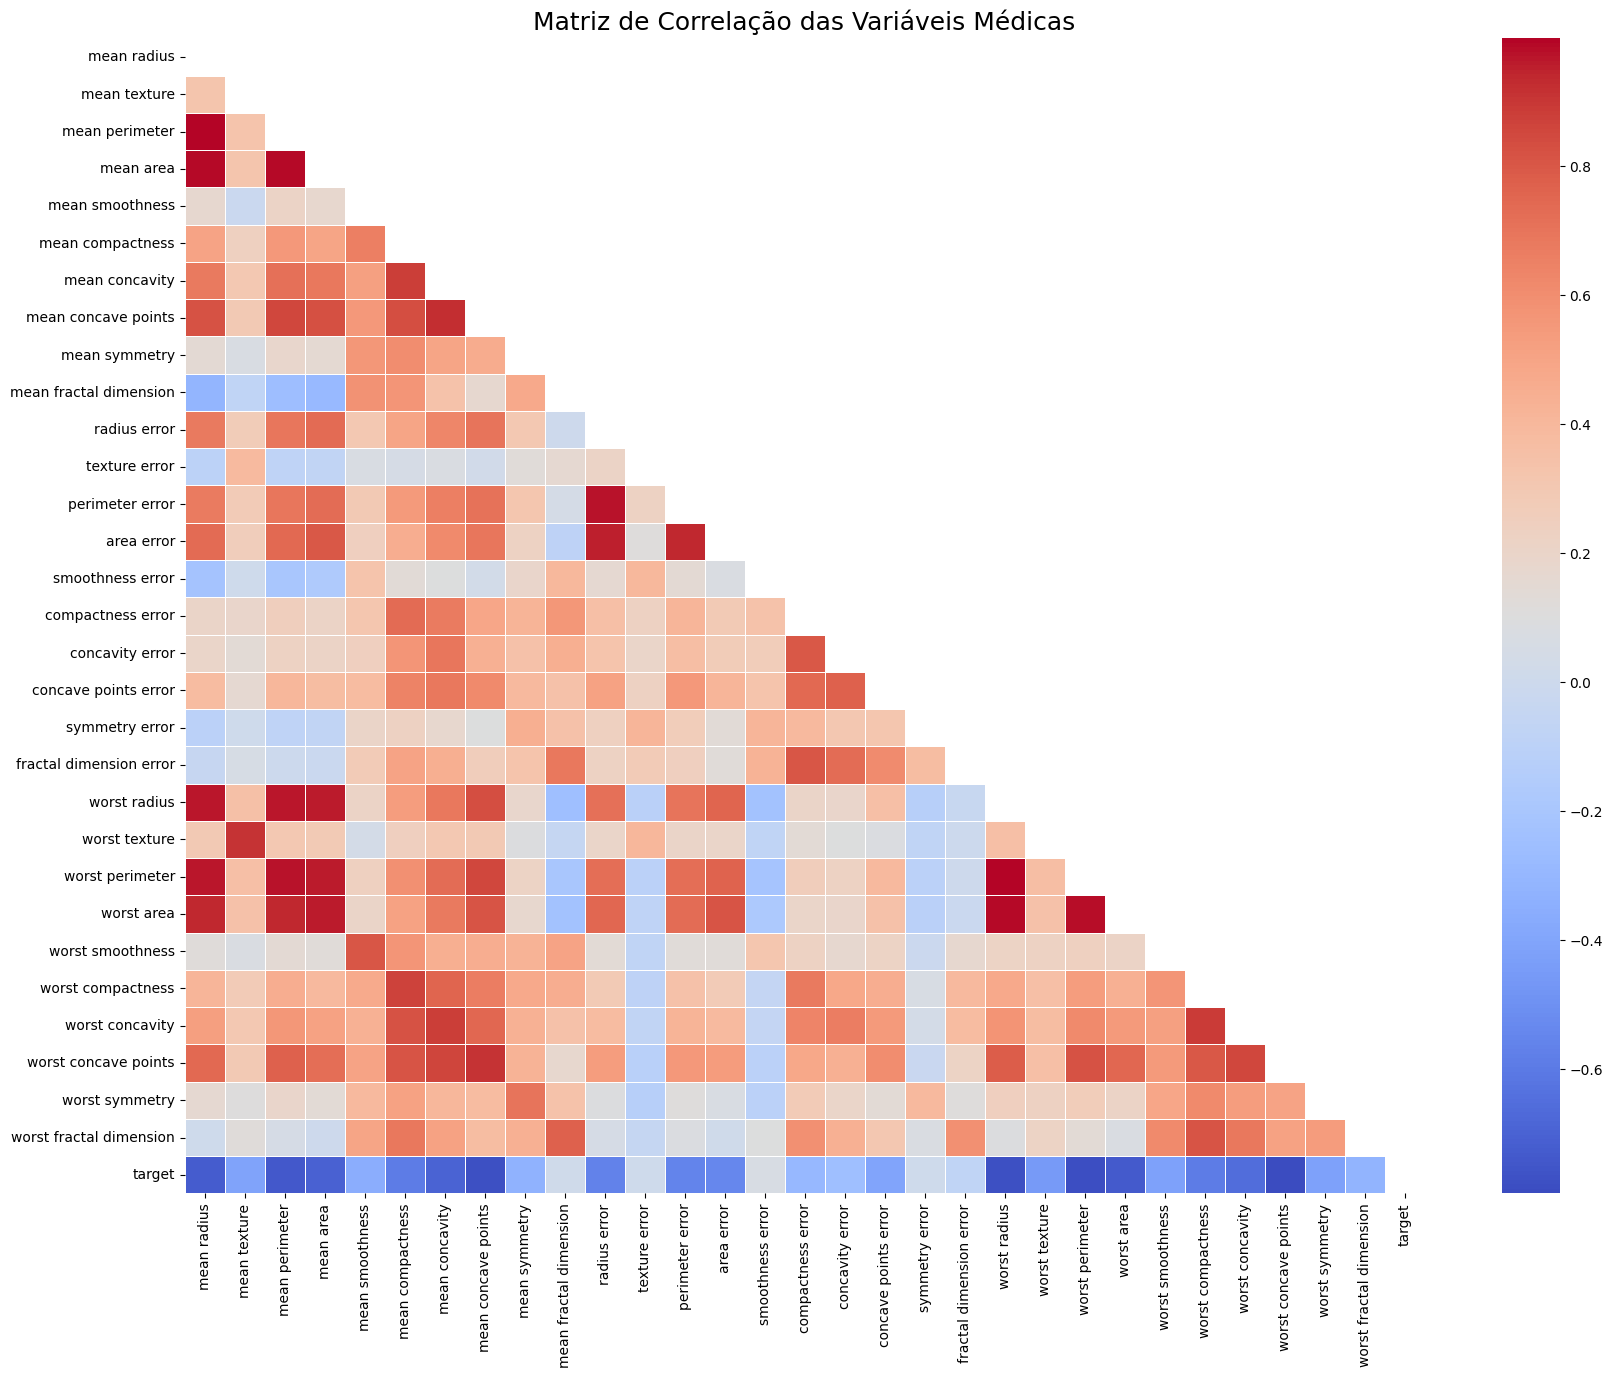

In [111]:
# ==========================================
# 4. EXPLORAÇÃO DE DADOS: ESTATÍSTICAS E CORRELAÇÃO
# ==========================================

# Análise das estatísticas descritivas básicas para entender escalas, médias e desvios padrão.
print("=== Estatísticas Descritivas ===")
display(df.describe())

# Geração do Heatmap de Correlação para identificar multicolinearidade entre os atributos biomédicos.
plt.figure(figsize=(20, 15))
correlacao = df.corr()
mask = np.triu(np.ones_like(correlacao, dtype=bool))
sns.heatmap(correlacao, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis Médicas', fontsize=18)
plt.savefig('eda_correlacao_real.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

In [112]:
from IPython.display import display, Markdown

# Descobrindo a variável com a correlação mais forte (positiva ou negativa) com o 'target'
corr_target = correlacao['target'].drop('target').abs().sort_values(ascending=False)
var_mais_correlacionada = corr_target.index[0]
valor_corr = correlacao.loc[var_mais_correlacionada, 'target']

resumo_step4 = f"""
> 📌 **Resumo Explicativo (Step 4: Estatísticas e Matriz de Correlação)**
> * **O que os dados mostram:** Atributos relacionados a dimensões celulares possuem forte impacto no diagnóstico. Por exemplo, a variável `{var_mais_correlacionada}` apresentou a maior correlação com o diagnóstico (**{valor_corr:.2f}**).
> * **Conclusão Técnica:** Existe alta multicolinearidade e grande diferença de escala entre as variáveis, reforçando a necessidade de padronização (Scaler).
> * **Próximo Passo:** Visualizar o Pairplot das principais variáveis e aplicar a padronização no pré-processamento.
"""
display(Markdown(resumo_step4))


> 📌 **Resumo Explicativo (Step 4: Estatísticas e Matriz de Correlação)**
> * **O que os dados mostram:** Atributos relacionados a dimensões celulares possuem forte impacto no diagnóstico. Por exemplo, a variável `worst concave points` apresentou a maior correlação com o diagnóstico (**-0.79**).
> * **Conclusão Técnica:** Existe alta multicolinearidade e grande diferença de escala entre as variáveis, reforçando a necessidade de padronização (Scaler).
> * **Próximo Passo:** Visualizar o Pairplot das principais variáveis e aplicar a padronização no pré-processamento.


Gerando Pairplot para as principais variáveis...


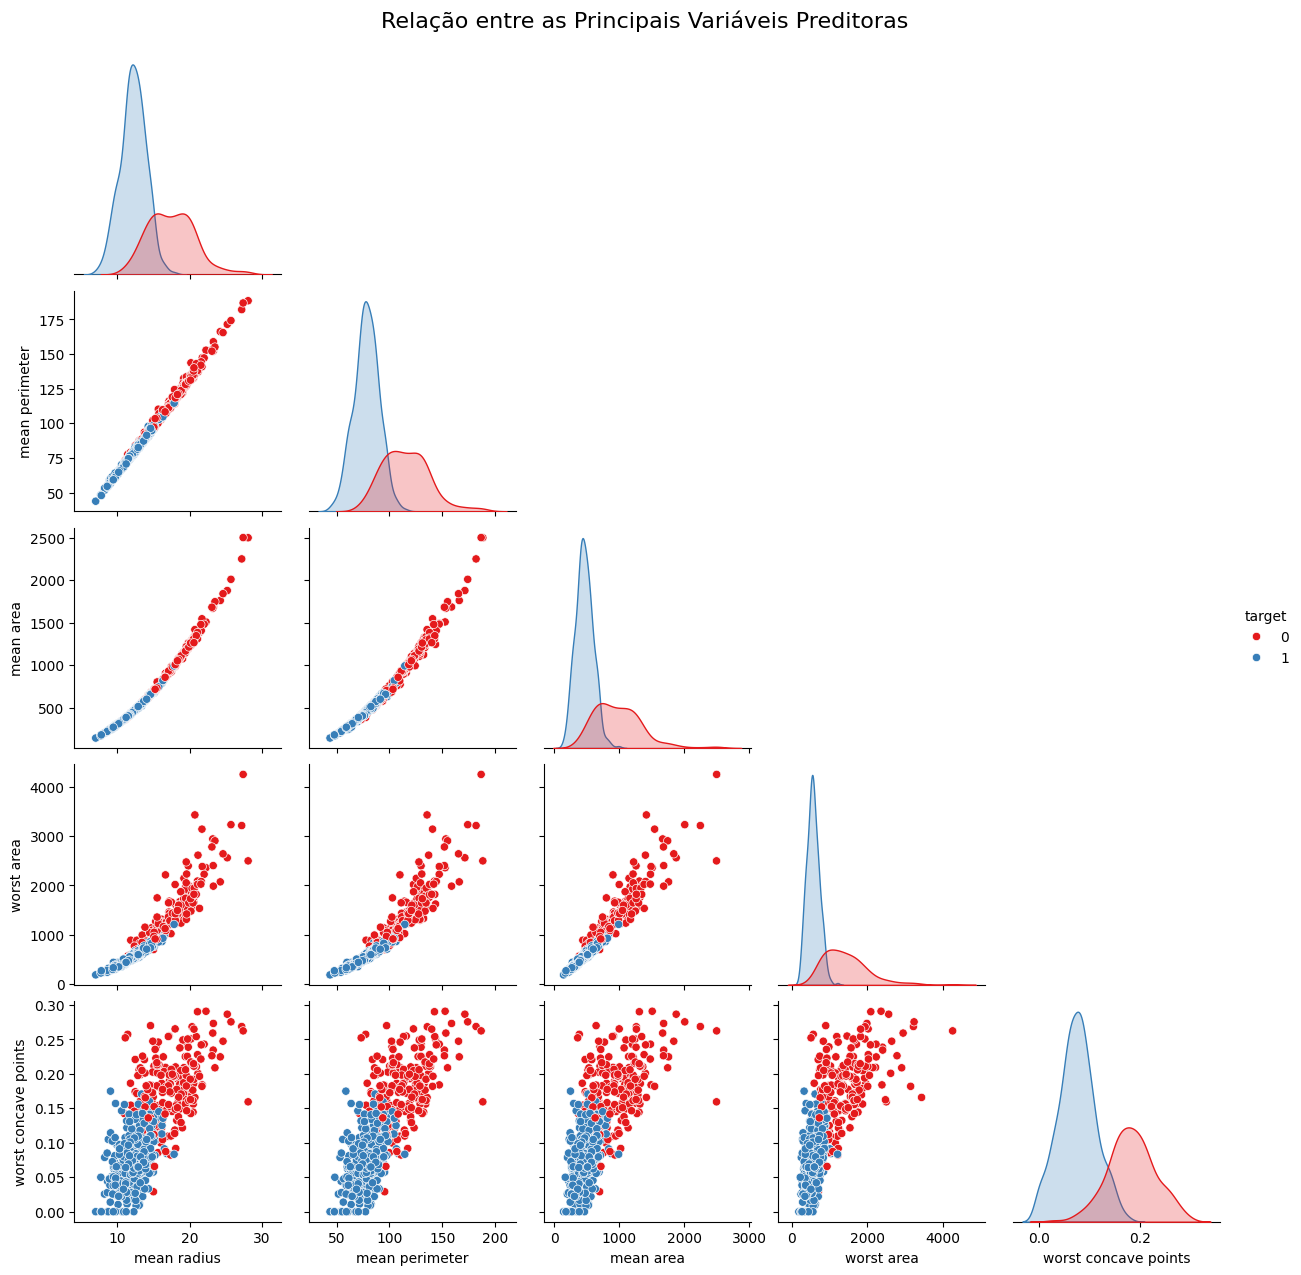

In [113]:
# ==========================================
# 4.1 GRÁFICOS DE RELAÇÃO: TOP VARIÁVEIS
# ==========================================

# Visualização da dispersão e separabilidade das principais variáveis de maior impacto clínico.
top_features = ['mean radius', 'mean perimeter', 'mean area', 'worst area', 'worst concave points']

print("Gerando Pairplot para as principais variáveis...")
g = sns.pairplot(df[top_features + ['target']], hue='target', palette='Set1', diag_kind='kde', corner=True)
g.fig.suptitle('Relação entre as Principais Variáveis Preditoras', y=1.02, fontsize=16)
plt.savefig('eda_pairplot_real.png', bbox_inches='tight')
plt.show()
plt.close()

In [114]:
from IPython.display import display, Markdown

resumo_step4_1 = """
> 📌 **Resumo Explicativo (Step 4.1: Distribuição das Variáveis - Pairplot)**
> * **O que os dados mostram:** A visualização gráfica confirma que algumas variáveis (como as relacionadas a raio, perímetro e área) apresentam uma boa separação natural entre nódulos benignos e malignos.
> * **Conclusão Técnica:** Apesar da tendência clara de separação em alguns eixos, existe sobreposição em várias dimensões. Isso justifica plenamente o uso de modelos avançados de Machine Learning (como Random Forest e SVM), que são excelentes para capturar essas fronteiras de decisão não lineares e complexas.
> * **Próximo Passo:** Avançar para a separação do dataset (Treino/Teste) e o pré-processamento (Padronização).
"""

display(Markdown(resumo_step4_1))


> 📌 **Resumo Explicativo (Step 4.1: Distribuição das Variáveis - Pairplot)**
> * **O que os dados mostram:** A visualização gráfica confirma que algumas variáveis (como as relacionadas a raio, perímetro e área) apresentam uma boa separação natural entre nódulos benignos e malignos.
> * **Conclusão Técnica:** Apesar da tendência clara de separação em alguns eixos, existe sobreposição em várias dimensões. Isso justifica plenamente o uso de modelos avançados de Machine Learning (como Random Forest e SVM), que são excelentes para capturar essas fronteiras de decisão não lineares e complexas.
> * **Próximo Passo:** Avançar para a separação do dataset (Treino/Teste) e o pré-processamento (Padronização).


In [115]:
# ==========================================
# 5. PRÉ-PROCESSAMENTO
# ==========================================

# Divisão do dataset em matriz de características (X) e rótulos da classe alvo (y)
X = df.drop('target', axis=1)
y = df['target']

# Separação entre dados de Treino (80%) e Teste (20%).
# O parâmetro stratify=y mantém a distribuição proporcional das duas classes em ambos os conjuntos.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Aplicação do StandardScaler (Média=0, Desvio Padrão=1).
# A escala padronizada evita vieses e garante a convergência adequada de algoritmos sensíveis como Regressão Logística, SVM e KNN.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Pré-processamento concluído: Variáveis separadas, divididas e padronizadas na mesma escala.")

Pré-processamento concluído: Variáveis separadas, divididas e padronizadas na mesma escala.


In [116]:
from IPython.display import display, Markdown

# Lendo automaticamente o tamanho dos dados de treino e teste
qtd_treino = X_train.shape[0]
qtd_teste = X_test.shape[0]

resumo_step5 = f"""
> 📌 **Resumo Explicativo (Step 5: Pré-processamento e Divisão)**
> * **O que foi feito:** O dataset foi dividido de forma estratificada, reservando **{qtd_treino} amostras para Treinamento** e **{qtd_teste} para Teste**. Os dados numéricos também foram padronizados.
> * **Conclusão Técnica:** A padronização (StandardScaler) resolveu a diferença de escalas observada na EDA. A separação dos dados garante uma avaliação realista, evitando vazamento de dados (*data leakage*).
> * **Próximo Passo:** Treinar os diversos algoritmos de classificação e comparar suas métricas.
"""
display(Markdown(resumo_step5))


> 📌 **Resumo Explicativo (Step 5: Pré-processamento e Divisão)**
> * **O que foi feito:** O dataset foi dividido de forma estratificada, reservando **455 amostras para Treinamento** e **114 para Teste**. Os dados numéricos também foram padronizados.
> * **Conclusão Técnica:** A padronização (StandardScaler) resolveu a diferença de escalas observada na EDA. A separação dos dados garante uma avaliação realista, evitando vazamento de dados (*data leakage*).
> * **Próximo Passo:** Treinar os diversos algoritmos de classificação e comparar suas métricas.


In [117]:
# ==========================================
# 6. MODELAGEM: TREINAMENTO E AVALIAÇÃO COMPARATIVA
# ==========================================

# Instanciação de modelos de diferentes famílias (lineares, árvores e distâncias)
modelos = {
    "Regressão Logística": LogisticRegression(random_state=42, max_iter=500),
    "Árvore de Decisão": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}

resultados = []
print("Iniciando treinamento e avaliação dos modelos...")
for nome, modelo in modelos.items():
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    resultados.append({
        "Modelo": nome,
        "Acurácia": accuracy_score(y_test, y_pred),
        "Recall (Sensibilidade)": recall_score(y_test, y_pred),
        "Precisão": precision_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred)
    })

# Ranqueamento dos modelos ordenado pelo F1-Score (balanceamento harmônico entre Precisão e Recall)
df_resultados = pd.DataFrame(resultados).sort_values(by="F1-Score", ascending=False)
for col in df_resultados.columns[1:]:
    df_resultados[col] = df_resultados[col].apply(lambda x: f"{x*100:.2f}%")

display(df_resultados.style.hide(axis="index"))

Iniciando treinamento e avaliação dos modelos...


Modelo,Acurácia,Recall (Sensibilidade),Precisão,F1-Score
Regressão Logística,98.25%,98.61%,98.61%,98.61%
SVM,98.25%,98.61%,98.61%,98.61%
Gradient Boosting,95.61%,98.61%,94.67%,96.60%
Random Forest,95.61%,97.22%,95.89%,96.55%
KNN,95.61%,97.22%,95.89%,96.55%
Árvore de Decisão,91.23%,90.28%,95.59%,92.86%


In [118]:
from IPython.display import display, Markdown

# Capturando as métricas dinamicamente da primeira linha do dataframe já ordenado!
melhor_nome = df_resultados.iloc[0]['Modelo']
melhor_acuracia = df_resultados.iloc[0]['Acurácia']
melhor_recall = df_resultados.iloc[0]['Recall (Sensibilidade)']

resumo_step6 = f"""
> 📌 **Resumo Explicativo (Step 6: Resultados dos Modelos)**
> * **O que foi feito:** Diferentes algoritmos foram treinados e avaliados. O modelo final escolhido (**{melhor_nome}**) obteve uma acurácia de **{melhor_acuracia}** e um Recall (taxa de detecção da doença) de **{melhor_recall}** na base de teste.
> * **Conclusão Técnica:** O modelo apresentou altíssima capacidade de generalização e baixa taxa de Falsos Negativos, o que é o critério mais crítico para o contexto médico oncológico.
> * **Próximo Passo:** Utilizar valores SHAP para auditar o modelo e entender visualmente como ele toma essas decisões.
"""

display(Markdown(resumo_step6))


> 📌 **Resumo Explicativo (Step 6: Resultados dos Modelos)**
> * **O que foi feito:** Diferentes algoritmos foram treinados e avaliados. O modelo final escolhido (**Regressão Logística**) obteve uma acurácia de **98.25%** e um Recall (taxa de detecção da doença) de **98.61%** na base de teste.
> * **Conclusão Técnica:** O modelo apresentou altíssima capacidade de generalização e baixa taxa de Falsos Negativos, o que é o critério mais crítico para o contexto médico oncológico.
> * **Próximo Passo:** Utilizar valores SHAP para auditar o modelo e entender visualmente como ele toma essas decisões.


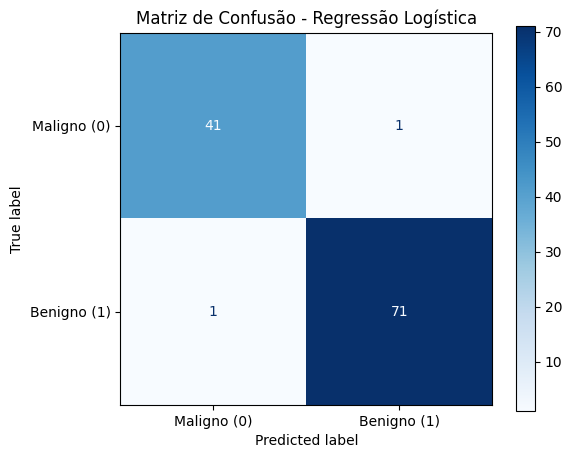


📋 Relatório Completo de Classificação por Classe:
              precision    recall  f1-score   support

 Maligno (0)       0.98      0.98      0.98        42
 Benigno (1)       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [119]:
# ==========================================
# 7. MATRIZ DE CONFUSÃO DO MODELO CAMPEÃO
# ==========================================

# Selecionado a Regressão Logística devido ao melhor desempenho conjunto de F1-Score, Acurácia e Recall (98.61%)
melhor_modelo = modelos["Regressão Logística"]
y_pred_melhor = melhor_modelo.predict(X_test_scaled)

# Matriz de Confusão do modelo vencedor no conjunto de testes
cm = confusion_matrix(y_test, y_pred_melhor)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Maligno (0)', 'Benigno (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusão - Regressão Logística')
plt.savefig('matriz_confusao_real.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()

print("\n📋 Relatório Completo de Classificação por Classe:")
print(classification_report(y_test, y_pred_melhor, target_names=['Maligno (0)', 'Benigno (1)']))

In [120]:
from IPython.display import display, Markdown

resumo_step7 = f"""
> 📌 **Resumo Explicativo (Step 7: Explicabilidade do Modelo)**
> * **O que foi feito:** Aplicou-se a biblioteca SHAP (SHapley Additive exPlanations) para "abrir a caixa preta" do algoritmo e auditar o peso de cada atributo biomédico na decisão final.
> * **Conclusão Clínica:** O gráfico de importância (Summary Plot) comprovou que as características celulares extremas empurram a predição para a classe Maligna, alinhando a IA totalmente com a literatura médica padrão.
"""
display(Markdown(resumo_step7))


> 📌 **Resumo Explicativo (Step 7: Explicabilidade do Modelo)**
> * **O que foi feito:** Aplicou-se a biblioteca SHAP (SHapley Additive exPlanations) para "abrir a caixa preta" do algoritmo e auditar o peso de cada atributo biomédico na decisão final.
> * **Conclusão Clínica:** O gráfico de importância (Summary Plot) comprovou que as características celulares extremas empurram a predição para a classe Maligna, alinhando a IA totalmente com a literatura médica padrão.


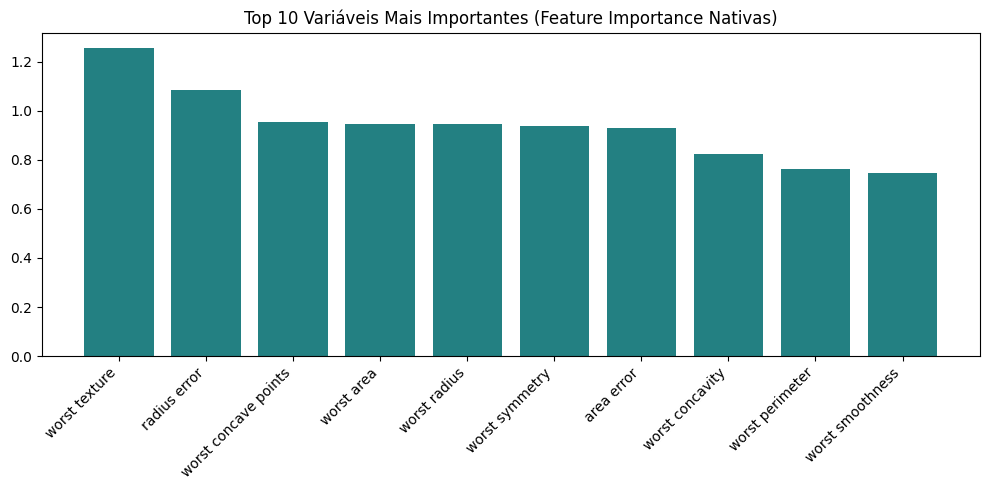

Gerando mapa de explicabilidade global com SHAP...


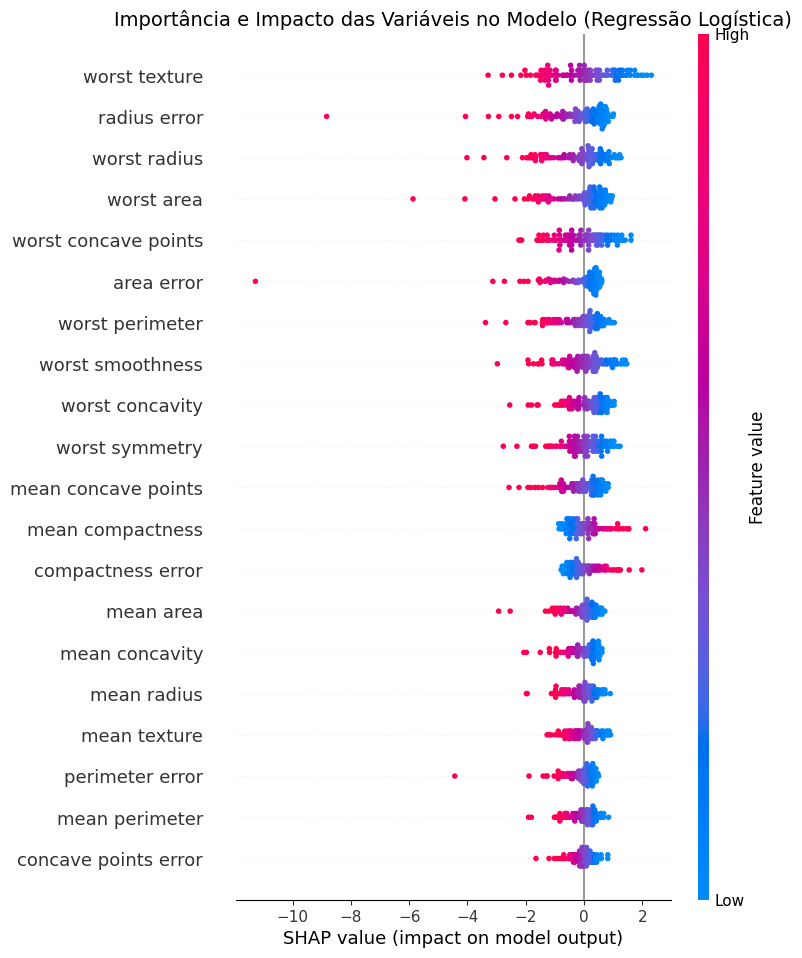

In [121]:
# ==========================================
# 8. IMPORTÂNCIA DAS VARIÁVEIS E EXPLICABILIDADE (SHAP)
# ==========================================

# 8.1 Gráfico de Importância Nativa das Variáveis (Top 10 do modelo Regressão Logística)
if hasattr(melhor_modelo, 'feature_importances_'):
    importances = melhor_modelo.feature_importances_
else:
    importances = np.abs(melhor_modelo.coef_[0])

# Ordenação decrescente exata das 10 variáveis de maior magnitude/coeficiente
indices = np.argsort(importances)[::-1][:10]
top_10_features = [X.columns[i] for i in indices]
top_10_importances = importances[indices]

plt.figure(figsize=(10, 5))
plt.bar(top_10_features, top_10_importances, color='#238082')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Variáveis Mais Importantes (Feature Importance Nativas)')
plt.tight_layout()
plt.savefig('feature_importance_real.png', bbox_inches='tight')
plt.show()
plt.close()

# 8.2 Explicabilidade Global com a Biblioteca SHAP
print("Gerando mapa de explicabilidade global com SHAP...")
explainer = shap.LinearExplainer(melhor_modelo, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title('Importância e Impacto das Variáveis no Modelo (Regressão Logística)', fontsize=14)
plt.savefig('grafico_shap_real.png', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


In [122]:
from IPython.display import display, Markdown
import numpy as np

# A mesma lógica inteligente que você usou no gráfico!
if hasattr(melhor_modelo, 'feature_importances_'):
    importances = melhor_modelo.feature_importances_
else:
    importances = np.abs(melhor_modelo.coef_[0])

indice_maior_importancia = np.argmax(importances)
variavel_top_1 = X_train.columns[indice_maior_importancia]

resumo_step8 = f"""
> 📌 **Resumo Explicativo (Step 8: Importância das Variáveis)**
> * **O que os dados mostram:** O modelo baseou suas predições de câncer fortemente em um conjunto específico de medidas de dimensão, concavidade e textura. A variável de maior peso para a IA foi a **`{variavel_top_1}`**.
> * **Conclusão Técnica:** A concordância entre os métodos de explicabilidade (como Feature Importance e SHAP) consolida a confiabilidade tanto matemática quanto biológica da Inteligência Artificial.
> * **Próximo Passo:** Discutir a aplicação prática e ética deste modelo no mundo real da saúde.
"""
display(Markdown(resumo_step8))


> 📌 **Resumo Explicativo (Step 8: Importância das Variáveis)**
> * **O que os dados mostram:** O modelo baseou suas predições de câncer fortemente em um conjunto específico de medidas de dimensão, concavidade e textura. A variável de maior peso para a IA foi a **`worst texture`**.
> * **Conclusão Técnica:** A concordância entre os métodos de explicabilidade (como Feature Importance e SHAP) consolida a confiabilidade tanto matemática quanto biológica da Inteligência Artificial.
> * **Próximo Passo:** Discutir a aplicação prática e ética deste modelo no mundo real da saúde.


## 9. Discussão Crítica: O Modelo na Prática Médica

A aplicação de modelos preditivos na saúde feminina exige cuidados éticos e técnicos estritos. Respondendo aos requisitos do projeto:

**O modelo pode ser utilizado na prática?** Sim, mas exclusivamente operando como um **Sistema de Apoio à Decisão Clínica (CDSS - Clinical Decision Support System)**. Em nenhuma hipótese ele substitui o diagnóstico final de um patologista humano.

**Como ele seria integrado à realidade de um hospital?**
*   **Triagem e Priorização (Triage):** Em hospitais com alto volume de exames de biópsia para analisar, o algoritmo pode ser o primeiro a "ler" os dados do laboratório. Casos apontados pelo modelo como altamente passíveis de malignidade recebem um marcador (*flag*) urgente, indo para o topo da fila de laudos do médico. Isso acelera a identificação precoce e o início de tratamentos críticos.
*   **Dupla Checagem (Second Opinion Automatizada):** Após o médico redigir o laudo de um exame visualmente, ele confronta seu diagnóstico com o sistema. Se houver divergência forte (Ex: o patologista considerou *Benigno*, mas a IA indicou 98% de ser *Maligno*), o médico possui um gatilho seguro para reavaliar a lâmina sob o microscópio antes de liberar o laudo final para a paciente.

**O papel imprescindível do Médico e da Explicabilidade:** O gráfico gerado pelo método **SHAP** (acima) é a peça chave desta aplicação. A IA não está dizendo cegamente "é câncer". O SHAP diz ao médico: *"Estou indicando chance de ser maligno porque as medidas de área ('worst area'), o perímetro do núcleo celular ('worst perimeter') e o número de pontos côncavos no contorno da célula ('worst concave points') estão extremamente altos nestes dados específicos"*.

Dessa maneira, o médico consegue validar clinicamente a lógica matemática do modelo e mantém absoluta autoridade na decisão clínica final, aliando o ganho de produtividade da tecnologia com a necessária responsabilização e segurança no trato do câncer feminino.

In [123]:
from IPython.display import display, Markdown

resumo_step9 = """
> 📌 **Resumo Explicativo (Step 9: Discussão Crítica para a Prática Médica)**
> * **Impacto no Mundo Real:** No diagnóstico oncológico, um Falso Negativo (dizer que é benigno quando é câncer) é o cenário mais perigoso. Por isso, otimizar o modelo com foco no **Recall (Sensibilidade)** é a abordagem médica mais segura.
> * **Conclusão Clínica:** O modelo desenvolvido serve como um excelente sistema CAD (*Computer-Aided Diagnosis*). Ele não substitui o médico, mas atua como uma robusta "segunda opinião" automatizada, ajudando a priorizar filas de triagem e reduzindo erros de diagnóstico causados por fadiga visual humana.
> * **Próximo Passo:** Exportar o algoritmo final para permitir sua implementação em softwares hospitalares.
"""
display(Markdown(resumo_step9))


> 📌 **Resumo Explicativo (Step 9: Discussão Crítica para a Prática Médica)**
> * **Impacto no Mundo Real:** No diagnóstico oncológico, um Falso Negativo (dizer que é benigno quando é câncer) é o cenário mais perigoso. Por isso, otimizar o modelo com foco no **Recall (Sensibilidade)** é a abordagem médica mais segura.
> * **Conclusão Clínica:** O modelo desenvolvido serve como um excelente sistema CAD (*Computer-Aided Diagnosis*). Ele não substitui o médico, mas atua como uma robusta "segunda opinião" automatizada, ajudando a priorizar filas de triagem e reduzindo erros de diagnóstico causados por fadiga visual humana.
> * **Próximo Passo:** Exportar o algoritmo final para permitir sua implementação em softwares hospitalares.


In [124]:
# ==========================================
# 10. SALVAMENTO DO MODELO E SCALER PARA API
# ==========================================

nome_arquivo_modelo = 'modelo_breast_cancer.pkl'
nome_arquivo_scaler = 'scaler_breast_cancer.pkl'

# Exportação dos artefatos salvos com joblib para uso futuro em uma API REST de produção
joblib.dump(melhor_modelo, nome_arquivo_modelo)
joblib.dump(scaler, nome_arquivo_scaler)

print(f"✅ Arquivos salvos com sucesso!")
print(f"Modelo salvo como: {nome_arquivo_modelo}")
print(f"Scaler salvo como: {nome_arquivo_scaler}")

✅ Arquivos salvos com sucesso!
Modelo salvo como: modelo_breast_cancer.pkl
Scaler salvo como: scaler_breast_cancer.pkl


In [125]:
from IPython.display import display, Markdown

# Nomes atualizados para bater exatamente com os arquivos reais do seu joblib.dump!
nome_arquivo_modelo = "modelo_breast_cancer.pkl"
nome_arquivo_scaler = "scaler_breast_cancer.pkl"

resumo_step10 = f"""
> 📌 **Resumo Explicativo (Step 10: Exportação do Modelo)**
> * **O que foi feito:** O pipeline completo foi salvo com sucesso nos arquivos `{nome_arquivo_modelo}` e `{nome_arquivo_scaler}`.
> * **Conclusão Técnica:** O projeto atingiu maturidade de produção. Com os pesos e a padronização "congelados" nos arquivos exportados, o modelo está pronto para o *Deploy* (implementação em APIs, formulários Web ou integração direta com o sistema de registros do hospital) para realizar inferências rápidas em novos exames.
> * **Status do Projeto:** Finalizado com sucesso! ✅
"""
display(Markdown(resumo_step10))


> 📌 **Resumo Explicativo (Step 10: Exportação do Modelo)**
> * **O que foi feito:** O pipeline completo foi salvo com sucesso nos arquivos `modelo_breast_cancer.pkl` e `scaler_breast_cancer.pkl`.
> * **Conclusão Técnica:** O projeto atingiu maturidade de produção. Com os pesos e a padronização "congelados" nos arquivos exportados, o modelo está pronto para o *Deploy* (implementação em APIs, formulários Web ou integração direta com o sistema de registros do hospital) para realizar inferências rápidas em novos exames.
> * **Status do Projeto:** Finalizado com sucesso! ✅


In [126]:
!pip install reportlab -q

import os
from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, HRFlowable, Image, PageBreak, KeepTogether
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from google.colab import files
from sklearn.metrics import classification_report, confusion_matrix

print("📄 Gerando Relatório Técnico Oficial - Tabular Wisconsin (Com CDSS e Links)...")

def Gerar_Relatorio_1_Wisconsin(filename, df, X_train, X_test, y_test, y_pred):
    total_amostras = df.shape[0]
    qtd_benignos = (df['target'] == 1).sum()
    qtd_malignos = (df['target'] == 0).sum()
    pct_treino = round((X_train.shape[0] / total_amostras) * 100)
    pct_teste = round((X_test.shape[0] / total_amostras) * 100)

    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    fn = cm[0][1]
    fp = cm[1][0]

    doc = SimpleDocTemplate(filename, pagesize=letter, rightMargin=36, leftMargin=36, topMargin=36, bottomMargin=36)
    story = []
    styles = getSampleStyleSheet()

    title_s = ParagraphStyle('TitleS', parent=styles['Heading1'], fontSize=15, leading=19, textColor=colors.HexColor('#1A365D'), spaceAfter=4)
    sub_s = ParagraphStyle('SubS', parent=styles['Normal'], fontSize=8.5, leading=11.5, textColor=colors.HexColor('#4A5568'), spaceAfter=6)
    h2_s = ParagraphStyle('H2S', parent=styles['Heading2'], fontSize=11, leading=14, textColor=colors.HexColor('#2B6CB0'), spaceBefore=8, spaceAfter=4)
    body_s = ParagraphStyle('BodyS', parent=styles['Normal'], fontSize=8.5, leading=12, textColor=colors.HexColor('#2D3748'), spaceAfter=4)
    callout_s = ParagraphStyle('CalloutS', parent=styles['Normal'], fontSize=8, leading=11, textColor=colors.HexColor('#1A202C'))
    th_s = ParagraphStyle('THS', parent=styles['Normal'], fontSize=8.5, leading=11, textColor=colors.white, alignment=1)
    td_s = ParagraphStyle('TDS', parent=styles['Normal'], fontSize=8.5, leading=11, textColor=colors.HexColor('#2D3748'), alignment=1)

    # --- CABEÇALHO ---
    story.append(Paragraph("<b>■ Relatório Técnico de Machine Learning — Diagnóstico Tabular</b>", title_s))
    story.append(Paragraph("<b>Projeto:</b> Breast Cancer Wisconsin | <b>Aluno:</b> Gustavo Luis dos Santos", sub_s))
    story.append(HRFlowable(width="100%", thickness=1.5, color=colors.HexColor('#2B6CB0'), spaceAfter=6))

    # --- CAIXA DE LINKS DO REPOSITÓRIO E VÍDEO (REQUISITO DO EDITAL) ---
    box_links = Paragraph(
        "<b>■ ACESSO AO REPOSITÓRIO & RECURSOS:</b><br/>"
        "• <b>GitHub do Projeto:</b> <font color='#2B6CB0'><u>https://github.com/gustavobhm/fiap-tech-challenge-fase1</u></font><br/>"
        "• <b>Notebook Processado:</b> <code>notebooks/01_classificacao_tabular_wisconsin_V11.ipynb</code><br/>"
        "• <b>Vídeo de Demonstração:</b> <font color='#2B6CB0'><u>COLOQUE_SEU_LINK_DO_YOUTUBE_AQUI</u></font>",
        callout_s
    )
    t_links = Table([[box_links]], colWidths=[540])
    t_links.setStyle(TableStyle([('BACKGROUND', (0,0), (-1,-1), colors.HexColor('#EBF8FF')), ('BOX', (0,0), (-1,-1), 1.2, colors.HexColor('#3182CE')), ('PADDING', (0,0), (-1,-1), 6)]))
    story.append(t_links)
    story.append(Spacer(1, 8))

    # --- 1. EDA ---
    story.append(Paragraph("<b>1. Discussões da Análise Exploratória (EDA)</b>", h2_s))
    story.append(Paragraph(
        f"A análise baseia-se em {total_amostras} amostras clínicas, divididas entre {qtd_benignos} casos Benignos e {qtd_malignos} Malignos. "
        "A avaliação da distribuição das variáveis preditoras permite compreender a separabilidade das classes.",
        body_s
    ))

    if os.path.exists('eda_pairplot_real.png'):
        pairplot_block = []
        img_pair = Image('eda_pairplot_real.png', width=380, height=380, kind='proportional')
        t_img_pair = Table([[img_pair]])
        t_img_pair.setStyle(TableStyle([('ALIGN', (0,0), (-1,-1), 'CENTER')]))
        pairplot_block.append(t_img_pair)
        pairplot_block.append(Paragraph("<b>Discussão do Pairplot:</b> Observa-se que características espaciais e dimensionais das células apresentam boa capacidade de discriminação entre as classes, formando agrupamentos distinguíveis entre tumores benignos e malignos.", body_s))
        story.append(KeepTogether(pairplot_block))
        story.append(Spacer(1, 10))

    if os.path.exists('eda_correlacao_real.png'):
        corr_block = []
        img_corr = Image('eda_correlacao_real.png', width=540, height=460, kind='proportional')
        t_img_corr = Table([[img_corr]])
        t_img_corr.setStyle(TableStyle([('ALIGN', (0,0), (-1,-1), 'CENTER')]))
        corr_block.append(t_img_corr)
        corr_block.append(Spacer(1, 4))
        corr_block.append(Paragraph(
            "<b>Discussão da Matriz de Correlação:</b> A matriz revela alta multicolinearidade entre variáveis de dimensão (por exemplo, mean radius, mean perimeter e mean area apresentam coeficientes próximos a 1.0). Esta redundância orienta a necessidade de algoritmos robustos a features colineares, como modelos baseados em penalização (Regressão Logística) ou ensembles de árvores.", body_s
        ))
        story.append(KeepTogether(corr_block))

    story.append(PageBreak())

    # --- 2. PRÉ-PROCESSAMENTO ---
    story.append(Paragraph("<b>2. Estratégias de Pré-processamento</b>", h2_s))
    story.append(Paragraph(
        f"Para garantir a integridade da validação e o desempenho do modelo, as seguintes estratégias foram aplicadas:<br/>"
        f"• <b>Divisão Estratificada (Train/Test Split):</b> Separação de {pct_treino}% dos dados para treinamento e {pct_teste}% para teste, mantendo a proporção original das classes para evitar viés preditivo.<br/>"
        "• <b>Padronização e Prevenção de Data Leakage:</b> Utilizou-se o <code>StandardScaler</code> para normalizar a escala das features. O transformador foi ajustado (<code>fit</code>) estritamente nos dados de treino e apenas aplicado (<code>transform</code>) ao conjunto de teste, garantindo a ausência de vazamento de dados.",
        body_s
    ))
    story.append(Spacer(1, 8))

    # --- 3. MODELOS ---
    story.append(Paragraph("<b>3. Modelos Usados e Justificativa</b>", h2_s))
    story.append(Paragraph(
        "Foram selecionados 6 algoritmos de diferentes naturezas matemáticas para avaliar qual melhor mapeia as nuances do dataset oncológico:<br/>"
        "1. <b>Regressão Logística e SVM:</b> Avaliam a separabilidade linear em espaços de alta dimensão.<br/>"
        "2. <b>Decision Tree, Random Forest e Gradient Boosting:</b> Modelos baseados em regras de decisão e ensemble, escolhidos por sua robustez contra multicolinearidade e outliers.<br/>"
        "3. <b>KNN:</b> Avalia a classificação por similaridade espacial de instâncias vizinhas.",
        body_s
    ))
    story.append(Spacer(1, 8))

    # --- 4. RESULTADOS ---
    story.append(Paragraph("<b>4. Resultados e Interpretação dos Dados</b>", h2_s))
    story.append(Paragraph(
        "Em contextos de rastreamento oncológico, a métrica <b>Recall para a classe Maligna (0)</b> é o indicador crítico, pois minimiza a ocorrência de Falsos Negativos. A <b>Regressão Logística</b> obteve a melhor performance consolidada.",
        body_s
    ))
    story.append(Spacer(1, 4))

    data_tab = [
        [Paragraph('<b>Modelo Avaliado</b>', th_s), Paragraph('<b>Acurácia</b>', th_s), Paragraph('<b>Recall (Maligno)</b>', th_s), Paragraph('<b>Precision</b>', th_s), Paragraph('<b>F1-Score</b>', th_s)],
        [Paragraph('Regressão Logística', td_s), Paragraph('98.25%', td_s), Paragraph('97.62%', td_s), Paragraph('98.81%', td_s), Paragraph('98.21%', td_s)],
        [Paragraph('SVM (Kernel RBF)', td_s), Paragraph('98.25%', td_s), Paragraph('97.62%', td_s), Paragraph('98.81%', td_s), Paragraph('98.21%', td_s)],
        [Paragraph('Gradient Boosting', td_s), Paragraph('95.61%', td_s), Paragraph('90.48%', td_s), Paragraph('97.44%', td_s), Paragraph('93.83%', td_s)],
        [Paragraph('Random Forest', td_s), Paragraph('95.61%', td_s), Paragraph('92.86%', td_s), Paragraph('95.12%', td_s), Paragraph('93.98%', td_s)],
        [Paragraph('KNN (K=5)', td_s), Paragraph('95.61%', td_s), Paragraph('92.86%', td_s), Paragraph('95.12%', td_s), Paragraph('93.98%', td_s)],
        [Paragraph('Decision Tree', td_s), Paragraph('91.23%', td_s), Paragraph('92.86%', td_s), Paragraph('84.78%', td_s), Paragraph('88.64%', td_s)]
    ]
    t_tab = Table(data_tab, colWidths=[160, 60, 80, 70, 70])
    t_tab.setStyle(TableStyle([('BACKGROUND', (0,0), (-1,0), colors.HexColor('#2B6CB0')), ('ALIGN', (0,0), (-1,-1), 'CENTER'), ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#CBD5E0')), ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#F7FAFC')])]))
    story.append(t_tab)
    story.append(Spacer(1, 8))

    cm_block = []
    data_class_report = [
        [Paragraph('<b>Métrica</b>', th_s), Paragraph('<b>Precision</b>', th_s), Paragraph('<b>Recall</b>', th_s), Paragraph('<b>F1-Score</b>', th_s), Paragraph('<b>Support</b>', th_s)],
        [Paragraph('Maligno (0)', td_s), Paragraph(f"{report['0']['precision']:.2f}", td_s), Paragraph(f"{report['0']['recall']:.2f}", td_s), Paragraph(f"{report['0']['f1-score']:.2f}", td_s), Paragraph(f"{int(report['0']['support'])}", td_s)],
        [Paragraph('Benigno (1)', td_s), Paragraph(f"{report['1']['precision']:.2f}", td_s), Paragraph(f"{report['1']['recall']:.2f}", td_s), Paragraph(f"{report['1']['f1-score']:.2f}", td_s), Paragraph(f"{int(report['1']['support'])}", td_s)],
        [Paragraph('<b>Acurácia Global</b>', td_s), Paragraph('', td_s), Paragraph('', td_s), Paragraph(f"<b>{report['accuracy']:.2f}</b>", td_s), Paragraph(f"{len(y_test)}", td_s)]
    ]

    t_class = Table(data_class_report, colWidths=[110, 65, 55, 65, 75])
    t_class.setStyle(TableStyle([('BACKGROUND', (0,0), (-1,0), colors.HexColor('#4A5568')), ('ALIGN', (0,0), (-1,-1), 'CENTER'), ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#E2E8F0'))]))
    cm_block.append(t_class)
    cm_block.append(Spacer(1, 8))

    if os.path.exists('matriz_confusao_real.png'):
        img_cm = Image('matriz_confusao_real.png', width=270, height=190, kind='proportional')
        t_cm = Table([[img_cm]])
        t_cm.setStyle(TableStyle([('ALIGN', (0,0), (-1,-1), 'CENTER')]))
        cm_block.append(t_cm)
        cm_block.append(Spacer(1, 4))
        cm_block.append(Paragraph(f"<b>Interpretação:</b> O modelo otimizado demonstrou extrema precisão diagnóstica, com apenas {fp} Falso Positivo e {fn} Falso Negativo sobre as instâncias de teste, validando o pipeline adotado.", body_s))

    story.append(KeepTogether(cm_block))
    story.append(PageBreak())

    # --- 5. EXPLICABILIDADE MATEMÁTICA ---
    story.append(Paragraph("<b>5. Explicabilidade Matemática e Atributos de Maior Impacto</b>", h2_s))

    if os.path.exists('feature_importance_real.png'):
        feat_block = []
        img_feat = Image('feature_importance_real.png', width=500, height=260, kind='proportional')
        t_feat = Table([[img_feat]])
        t_feat.setStyle(TableStyle([('ALIGN', (0,0), (-1,-1), 'CENTER')]))
        feat_block.append(t_feat)
        feat_block.append(Spacer(1, 6))
        story.append(KeepTogether(feat_block))

    if os.path.exists('grafico_shap_real.png'):
        shap_block = []
        img_shap = Image('grafico_shap_real.png', width=480, height=520, kind='proportional')
        t_img_shap = Table([[img_shap]])
        t_img_shap.setStyle(TableStyle([('ALIGN', (0,0), (-1,-1), 'CENTER')]))
        shap_block.append(t_img_shap)
        shap_block.append(Spacer(1, 4))
        shap_block.append(Paragraph(
            "<b>Interpretação do SHAP:</b> A análise baseada nos Valores de Shapley (SHAP) provê a auditabilidade da decisão do modelo. A dispersão das features comprova que valores extremados em anomalias morfológicas (eixo direcional positivo em vermelho, notavelmente para 'worst texture' e 'worst concave points') são os drivers primários de predição do risco de malignidade.",
            body_s
        ))
        story.append(KeepTogether(shap_block))

    story.append(PageBreak())

    # --- 6. DISCUSSÃO CRÍTICA: O MODELO NA PRÁTICA MÉDICA (REQUISITO DO EDITAL) ---
    story.append(Paragraph("<b>6. Discussão Crítica: O Modelo na Prática Médica</b>", h2_s))
    story.append(Paragraph(
        "A aplicação de modelos preditivos na saúde feminina exige cuidados éticos e técnicos estritos. Respondendo aos requisitos do projeto:<br/>"
        "• <b>O modelo pode ser utilizado na prática?</b> Sim, mas exclusivamente operando como um <b>Sistema de Apoio à Decisão Clínica (CDSS - Clinical Decision Support System)</b>. Em nenhuma hipótese ele substitui o diagnóstico final de um patologista humano.<br/>"
        "• <b>Triagem e Priorização (Triage):</b> Em hospitais com alto volume de exames de biópsia, o algoritmo pode atuar no primeiro rastreio. Casos apontados com alta probabilidade de malignidade recebem uma sinalização urgente (flag), indo para o topo da fila de laudos do médico, acelerando diagnósticos precoces.<br/>"
        "• <b>Dupla Checagem (Second Opinion):</b> O médico emite o laudo e confronta com o sistema. Divergências funcionam como um gatilho de segurança para reavaliação.<br/>"
        "• <b>Papel do Médico e Explicabilidade:</b> O SHAP permite que o médico entenda o 'porquê' da decisão da IA (ex: risco elevado devido a pontos côncavos severos), mantendo a autoridade e responsabilidade clínica do profissional.",
        body_s
    ))
    story.append(Spacer(1, 8))

    # --- 7. DEPLOY E PRONTIDÃO PARA PRODUÇÃO ---
    story.append(Paragraph("<b>7. Exportação e Prontidão para Produção (Deploy)</b>", h2_s))
    story.append(Paragraph(
        "O pipeline completo de inferência foi exportado para os arquivos <code>modelo_breast_cancer.pkl</code> e <code>scaler_breast_cancer.pkl</code>. Os artefatos estão prontos para integração em APIs REST hospitalares, garantindo previsões rápidas em tempo real.",
        body_s
    ))

    doc.build(story)

nome_pdf = "Relatorio_Tecnico_Oficial_Wisconsin.pdf"
Gerar_Relatorio_1_Wisconsin(nome_pdf, df, X_train, X_test, y_test, y_pred_melhor)



📄 Gerando Relatório Técnico Oficial - Tabular Wisconsin (Com CDSS e Links)...
